# Reference design 1 — Transmon with readout resonator

Build the canonical superconducting-qubit unit cell: one fixed-frequency transmon dispersively coupled to a meandered lambda/4 readout resonator on a shared coplanar-waveguide feedline.

> **Reference design — attribution.** Adapted, with attribution, from the open-source [SQDMetal](https://github.com/sqdlab/SQDMetal) project (Apache-2.0) and its benchmark devices in D. Sommers, P. Pakkiam, Z. Degnan, C.-C. Chiu, D. Gautam, Y.-H. Chen, and A. Fedorov, *"Open-Source Highly Parallel Electromagnetic Simulations for Superconducting Circuits,"* [arXiv:2511.01220](https://arxiv.org/abs/2511.01220) (2025). Re-implemented here with stock Quantum Metal components.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt):
# !pip install -q quantum-metal

In [2]:
import qiskit_metal as qm
from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

design = designs.DesignPlanar()
design.overwrite_enabled = True

06:59PM 24s INFO [_start_renderers]: Renderer=gmsh skipped: runtime dependency not installed (renderer_gmsh requires gmsh. Install with: pip install 'quantum-metal[mesh]' (or the legacy alias 'quantum-metal[fem]')).


## 1. The transmon qubit

A single `TransmonPocket` with one readout connection pad on its top-right corner.

In [3]:
TransmonPocket(design, 'Q1', options=dict(
    pos_x='0mm', pos_y='-1.5mm', pad_width='425um', pocket_height='650um',
    connection_pads=dict(readout=dict(loc_W=+1, loc_H=+1))))

name:    Q1
class:   TransmonPocket        
options: 
  'pos_x'             : '0mm',                        
  'pos_y'             : '-1.5mm',                     
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'connection_pads'   : {
       'readout'           : {
            'pad_gap'           : '15um',                       
            'pad_width'         : '125um',                      
            'pad_height'        : '30um',                       
            'pad_cpw_shift'     : '5um',                        
            'pad_cpw_extent'    : '25um',                       
            'cpw_width'         : 'cpw_width',                  
            'cpw_gap'           : 'cpw_gap',                    
            'cpw_extend'        : '100um',                      
            'pocket_extent'     : '5um',                        
            'pocket_rise'    

## 2. Feedline + readout resonator

A coplanar feedline runs between two wirebond launchpads through a **coupled-line tee**, which capacitively taps off a meandered lambda/4 resonator down to the qubit. `total_length` sets the resonator frequency.

In [4]:
CoupledLineTee(design, 'clt', options=dict(
    pos_x='0mm', pos_y='1.5mm', coupling_length='350um', down_length='300um',
    fillet='90um', open_termination=False))
LaunchpadWirebond(design, 'LP1', options=dict(pos_x='-4mm', pos_y='1.5mm', orientation='0'))
LaunchpadWirebond(design, 'LP2', options=dict(pos_x='4mm', pos_y='1.5mm', orientation='180'))

RoutePathfinder(design, 'feed_L', options=dict(fillet='90um', pin_inputs=Dict(
    start_pin=Dict(component='LP1', pin='tie'), end_pin=Dict(component='clt', pin='prime_start'))))
RoutePathfinder(design, 'feed_R', options=dict(fillet='90um', pin_inputs=Dict(
    start_pin=Dict(component='clt', pin='prime_end'), end_pin=Dict(component='LP2', pin='tie'))))

RouteMeander(design, 'readout_res', options=dict(
    fillet='90um', total_length='7mm',
    lead=Dict(start_straight='100um', end_straight='100um'),
    pin_inputs=Dict(start_pin=Dict(component='clt', pin='second_end'),
                    end_pin=Dict(component='Q1', pin='readout'))))

name:    readout_res
class:   RouteMeander          
options: 
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'pin_inputs'        : {
       'start_pin'         : {
            'component'         : 'clt',                        
            'pin'               : 'second_end',                 
                             },
       'end_pin'           : {
            'component'         : 'Q1',                         
            'pin'               : 'readout',                    
                             },
                        },
  'fillet'            : '90um',                       
  'lead'              : {
       'start_straight'    : '100um',                      
       'end_straight'      : '100um',                      
       'start_jogged_extension': '',                           
       'end_jogged_extension': '',                           
                        },
  'total_length'      : '7mm',    

## 3. Visualize

## Next steps

- **Inspect** the design tree: `design.components.keys()` and `design.qgeometry.tables`.
- **Export GDS** for fabrication: `design.renderers.gds.export_to_gds('chip.gds')` (Quantum Metal uses the modern `gdstk` backend).
- **Simulate**: render to Ansys HFSS/Q3D (the validation gold standard) or to the open-source FEM path (Gmsh + Elmer today; AWS Palace on the roadmap) to extract eigenmodes, *Q*, and the capacitance matrix.
- **Tweak**: every dimension above is a parameter — change `total_length` to retune resonator frequencies, or `pos_x`/`pos_y` to relayout.

In [5]:
design.components.keys()

['Q1', 'clt', 'LP1', 'LP2', 'feed_L', 'feed_R', 'readout_res']

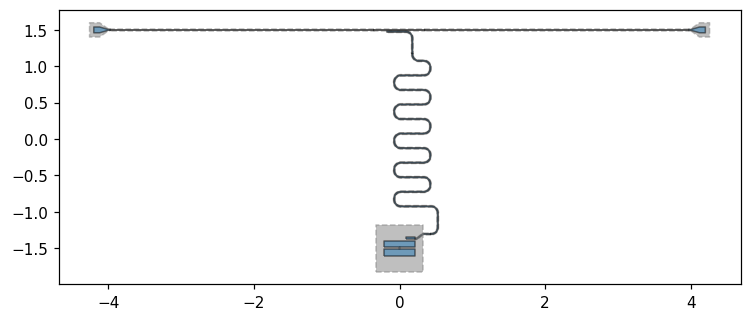

In [6]:
fig = qm.view(design)
try:
    qm.show_inline(fig)
except Exception:
    from IPython.display import display; display(fig)